# Statistical hypothesis testing

Two groups of tests are performed on the training data:

1. **Normality of numeric features** — Pearson chi-squared test for a composite
   hypothesis (parameters estimated from the sample). Transferred from EDA
   (`01_eda.ipynb`) with two fixes: sample size is taken **after** row filtering
   and the significance level is set to the standard `alpha = 0.05`.
2. **Feature–target dependence** — since most features turn out to be non-normal,
   the non-parametric Kruskal–Wallis H-test is used for numeric features;
   for categorical features — the chi-squared test of independence with
   Cramér's V as an effect size.

Rows with 3 or more missing values are dropped beforehand (same rule as in EDA).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("datasets/train.csv")
# drop samples with 3+ missing values (<= 0.2% of data, see 01_eda.ipynb)
df = df[~(df.isnull().sum(axis=1) >= 3)]
print(f"Samples after filtering: {len(df)}")

numeric_cols = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure",
                "step_count", "exercise_duration", "water_intake"]
categorical_cols = ["diet_type", "stress_level", "sleep_quality",
                    "physical_activity_level", "smoking_alcohol", "gender"]
target = "health_condition"


Samples after filtering: 675068


## 1. Normality tests (Pearson chi-squared, composite hypothesis)

H0: the feature follows a normal distribution. Mean and variance are estimated
from the sample, so the degrees of freedom are `K - 1 - 2` (K — number of bins).
Bins are merged so that every expected count is greater than 5.

In [ ]:
alpha = 0.05  # significance level

for column in numeric_cols:
    data = df[column].dropna()  # test on observed (non-NaN) values only
    n = len(data)
    expected_value = data.sum() / n
    dispersion = np.sum((data - expected_value) ** 2) / (n - 1)
    std_dev = np.sqrt(dispersion)

    b = 10
    counts, bin_edges = np.histogram(data, bins=b)

    # merge adjacent bins while any count <= 5
    if any(i < 5 for i in counts):
        new_counts = []
        new_bin_edges = [bin_edges[0]]

        i = 0
        n_bins = len(counts)

        while i < n_bins:
            local_count = counts[i]

            while local_count <= 5 and i < n_bins - 1:
                i += 1
                local_count += counts[i]

            new_counts.append(local_count)
            new_bin_edges.append(bin_edges[i + 1])
            i += 1

        if len(new_counts) > 1 and new_counts[-1] <= 5:
            last_count = new_counts.pop()
            new_counts[-1] += last_count
            new_bin_edges.pop(-2)

        counts = np.array(new_counts)
        bin_edges = np.array(new_bin_edges)

    theoretical_probs = []
    for k in range(len(counts)):
        low = -np.inf if k == 0 else bin_edges[k]
        high = np.inf if k == len(counts) - 1 else bin_edges[k + 1]
        p = stats.norm.cdf(high, loc=expected_value, scale=std_dev) - \
            stats.norm.cdf(low, loc=expected_value, scale=std_dev)
        theoretical_probs.append(p)
    theoretical_probs = np.array(theoretical_probs)

    expected_counts = theoretical_probs * n

    chi2_stat = np.sum((counts - expected_counts) ** 2 / expected_counts)

    c = 2
    degrees_of_freedom = len(counts) - 1 - c

    if degrees_of_freedom <= 0:
        print(f"Column {column}: not enough bins ({len(counts)}) for the test.")
        continue

    p_value = 1 - stats.chi2.cdf(chi2_stat, df=degrees_of_freedom)

    print(f"--- Normality test for column: {column} (n={n}) ---")
    print(f"Bins after merging: {len(counts)}")
    print(f"Chi-squared statistic: {chi2_stat:.4f}")
    print(f"Degrees of freedom: {degrees_of_freedom}")
    print(f"p-value: {p_value:.6f}")

    if p_value < alpha:
        print("Conclusion: reject H0. The distribution differs from normal.")
    else:
        print("Conclusion: fail to reject H0. The distribution is consistent with normal.")
    print()


--- Normality test for column: sleep_duration (n=606294) ---
Bins after merging: 10
Chi-squared statistic: 1337.9104
Degrees of freedom: 7
p-value: 0.000000
Conclusion: reject H0. The distribution differs from normal.

--- Normality test for column: heart_rate (n=668229) ---
Bins after merging: 10
Chi-squared statistic: 1468.5238
Degrees of freedom: 7
p-value: 0.000000
Conclusion: reject H0. The distribution differs from normal.

--- Normality test for column: bmi (n=662884) ---
Bins after merging: 10
Chi-squared statistic: 90.4555
Degrees of freedom: 7
p-value: 0.000000
Conclusion: reject H0. The distribution differs from normal.

--- Normality test for column: calorie_expenditure (n=627826) ---
Bins after merging: 10
Chi-squared statistic: 15890.5056
Degrees of freedom: 7
p-value: 0.000000
Conclusion: reject H0. The distribution differs from normal.

--- Normality test for column: step_count (n=662925) ---
Bins after merging: 10
Chi-squared statistic: 37851.5911
Degrees of freedom: 7

## 2. Feature–target dependence

### 2.1 Numeric features — Kruskal–Wallis H-test

H0: the distributions of a feature are identical across the three target classes.
A non-parametric test is chosen because Section 1 shows the features are not
normal. Effect size: epsilon-squared `(H - k + 1) / (n - k)`.

In [ ]:
numeric_results = []
for col in numeric_cols:
    groups = [g[col].dropna() for _, g in df.groupby(target)]
    H, p = stats.kruskal(*groups)
    k, n = len(groups), sum(len(g) for g in groups)
    eps_sq = (H - k + 1) / (n - k) 
    numeric_results.append({"feature": col, "test": "Kruskal-Wallis",
                            "statistic": H, "p_value": p, "effect_size": eps_sq})

numeric_results = pd.DataFrame(numeric_results).sort_values("effect_size", ascending=False)
numeric_results


,feature,test,statistic,p_value,effect_size
0,sleep_duration,Kruskal-Wallis,117970.646010,0.000000e+00,0.194574
5,exercise_duration,Kruskal-Wallis,25723.681624,0.000000e+00,0.038446
4,step_count,Kruskal-Wallis,25395.997620,0.000000e+00,0.038306
2,bmi,Kruskal-Wallis,13025.863385,0.000000e+00,0.019647
3,calorie_expenditure,Kruskal-Wallis,5453.493954,0.000000e+00,0.008683
1,heart_rate,Kruskal-Wallis,100.104308,1.830736e-22,0.000147
6,water_intake,Kruskal-Wallis,34.151302,3.838301e-08,0.000051


### 2.2 Categorical features — chi-squared test of independence

H0: a feature is independent of the target. Effect size: Cramér's V
`sqrt(chi2 / (n * (min(r, c) - 1)))`.

In [ ]:
categorical_results = []
for col in categorical_cols:
    ct = pd.crosstab(df[col], df[target])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    categorical_results.append({"feature": col, "test": "chi2 independence",
                                "statistic": chi2, "p_value": p, "effect_size": cramers_v})

categorical_results = pd.DataFrame(categorical_results).sort_values("effect_size", ascending=False)
categorical_results


,feature,test,statistic,p_value,effect_size
1,stress_level,chi2 independence,204113.149065,0.000000e+00,0.412453
3,physical_activity_level,chi2 independence,74504.790331,0.000000e+00,0.240768
2,sleep_quality,chi2 independence,17946.485669,0.000000e+00,0.120039
4,smoking_alcohol,chi2 independence,7653.543253,0.000000e+00,0.076741
0,diet_type,chi2 independence,314.780804,7.013679e-67,0.015338
5,gender,chi2 independence,224.716655,1.810722e-47,0.013088


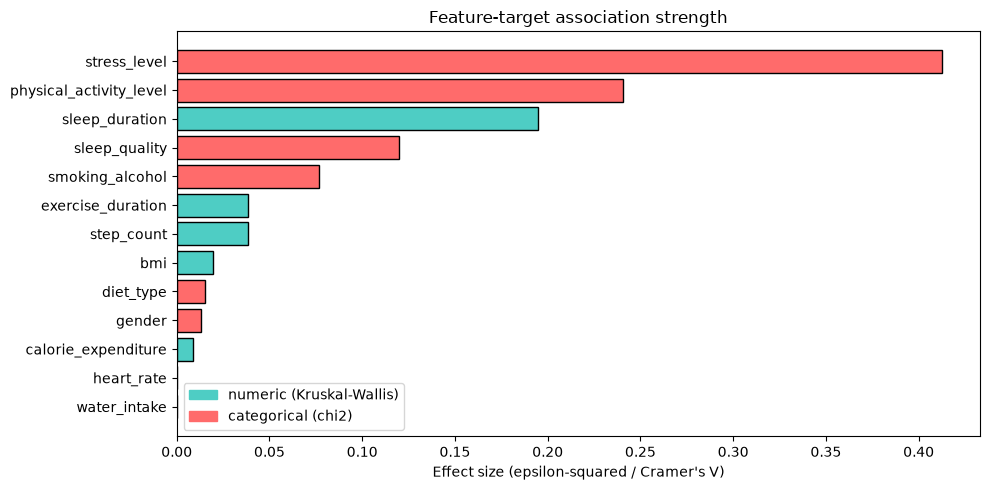

,feature,test,statistic,p_value,effect_size
0,stress_level,chi2 independence,204113.149065,0.000000e+00,0.412453
1,physical_activity_level,chi2 independence,74504.790331,0.000000e+00,0.240768
2,sleep_duration,Kruskal-Wallis,117970.646010,0.000000e+00,0.194574
3,sleep_quality,chi2 independence,17946.485669,0.000000e+00,0.120039
4,smoking_alcohol,chi2 independence,7653.543253,0.000000e+00,0.076741
5,exercise_duration,Kruskal-Wallis,25723.681624,0.000000e+00,0.038446
6,step_count,Kruskal-Wallis,25395.997620,0.000000e+00,0.038306
7,bmi,Kruskal-Wallis,13025.863385,0.000000e+00,0.019647
8,diet_type,chi2 independence,314.780804,7.013679e-67,0.015338
9,gender,chi2 independence,224.716655,1.810722e-47,0.013088


In [5]:
all_results = pd.concat([numeric_results, categorical_results])
all_results = all_results.sort_values("effect_size", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4ECDC4" if t == "Kruskal-Wallis" else "#FF6B6B" for t in all_results["test"]]
ax.barh(all_results["feature"], all_results["effect_size"], color=colors, edgecolor="black")
ax.set_xlabel("Effect size (epsilon-squared / Cramer's V)")
ax.set_title("Feature-target association strength")
ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#4ECDC4", label="numeric (Kruskal-Wallis)"),
                   Patch(color="#FF6B6B", label="categorical (chi2)")])
plt.tight_layout()
plt.savefig("feature_target_association.png", dpi=300, bbox_inches="tight")
plt.show()

all_results


## Conclusions

1. **Normality**: all seven numeric features deviate from a normal distribution
   (with ~0.5M samples the test is very powerful, so even small deviations are
   detected). This justifies the choice of **RobustScaler** (median/IQR-based)
   over StandardScaler in the preprocessing pipeline.
2. **Dependence**: every feature shows a statistically significant association
   with the target (p < 0.05), but the effect sizes differ strongly —
   lifestyle features (`stress_level`, `physical_activity_level`, sleep-related
   features) dominate, while `gender` and `diet_type` are weak. This ranking is
   later confirmed by model-based feature importance (see `07_model_analysis.ipynb`).